In [1]:
from utils import get_match_df, analyze_strategies

df = get_match_df()

In [2]:
import numpy as np
import pandas as pd

def get_best_strategies(df, n_weeks: int = 4):
    """
    n_weeks: no. of rolling weeks to evaluate
    """
    last_week = max(df["week"])
    df = df.sort_values(by="date", ascending=False)
    week_df = df[df["week"] >= last_week - n_weeks]

    available_strategies = week_df[week_df["week"] == last_week]["strategy"].unique()

    strategy_dict = dict()

    # Removing week 7 considering it an outlier
    # week_df = week_df[week_df["week"] != 7]
    for strategy in available_strategies:
        gain = week_df[week_df['strategy'] == strategy].groupby("week")["return"].sum().mean()
        counts = week_df[week_df['strategy'] == strategy].groupby("week").size().to_list()

        while len(counts) < n_weeks:
            counts += [0]
        
        counts = np.mean(counts)

        accuracy = (week_df[week_df['strategy'] == strategy].groupby("week")["result"].sum() / counts).mean()
        # if gain > 10:
        #     continue
        strategy_dict = strategy_dict | {strategy: [gain, counts, accuracy]}

    strategy_df = pd.DataFrame(strategy_dict, index=["weekly_gain", "weekly_counts", "accuracy"]).T.sort_values(by='weekly_gain', ascending=False)
    return strategy_df 


foo = get_best_strategies(df, n_weeks=10)
foo

,weekly_gain,weekly_counts,accuracy
BTTS,3.207778,6.0,0.759259
DNB 1,0.922222,8.6,0.878553
Over 1.5 (M2-X),0.714286,7.3,1.017613
Goal HT,0.400000,5.0,0.720000
Win x2 HT,0.400000,2.2,0.795455
Over 0.5 HT (Live),0.371429,5.2,1.153846
Win 2,0.277778,1.7,0.849673
CN Home (Asiatic),0.233333,3.1,0.967742
Win 1,0.111111,2.0,0.777778
Multigoal 1-2 Home,-0.160000,0.7,1.142857


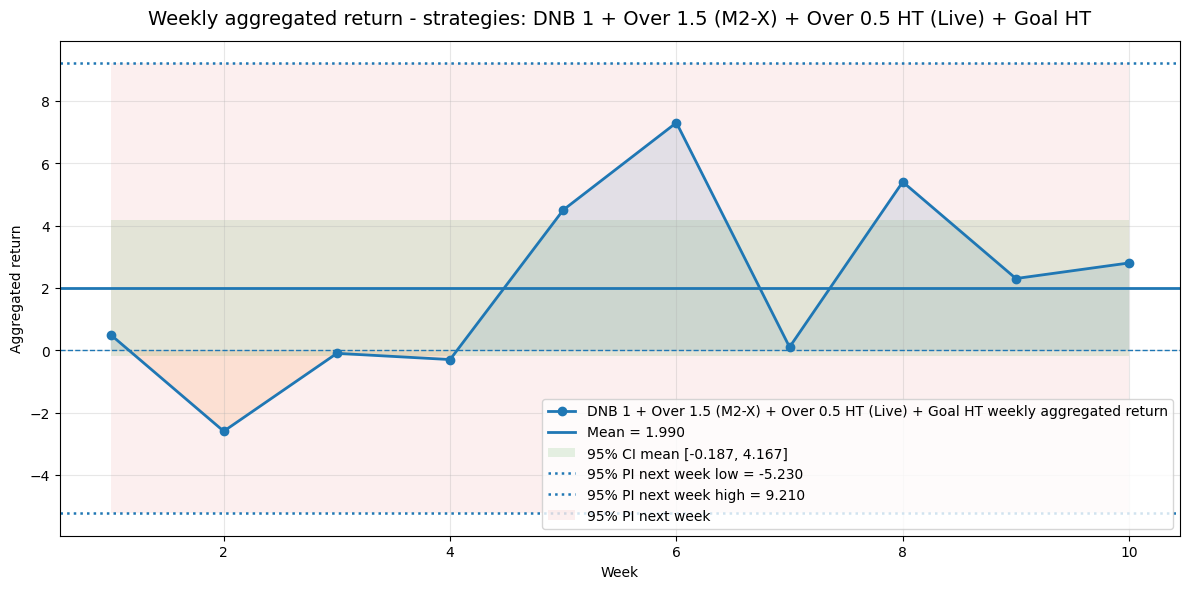

{'strategy': ['DNB 1', 'Over 1.5 (M2-X)', 'Over 0.5 HT (Live)', 'Goal HT'], 'n_weeks': 10, 'mean_weekly_agg_return': np.float64(1.9900000000000002), 'std_weekly_agg_return': np.float64(3.043189116699782), 'sem': np.float64(0.9623408959407264), 'ci_low': np.float64(-0.18696635085974522), 'ci_high': np.float64(4.166966350859745), 'pi_low': np.float64(-5.230180567030964), 'pi_high': np.float64(9.210180567030964)}


In [3]:
weekly_returns, stats = analyze_strategies(df, ["DNB 1", "Over 1.5 (M2-X)", "Over 0.5 HT (Live)", "Goal HT"], print_pi=True)
print(stats)